# 02b · One refractiveindex.info model, every engine

`02_technology` showed that the engines' *shipped* material models agree with
refractiveindex.info. This notebook takes a real measured model straight from
refractiveindex.info — its full complex, wavelength-dependent `n(λ) + i·k(λ)` —
and feeds that exact model into each FDTD engine.

The material is **gold (Johnson & Christy 1972)** — a strongly dispersive,
strongly *lossy* material where the imaginary part carries real weight (k runs
from ~3 in the visible to ~11 in the near-IR). If a model is going to break on
the trip into an engine, it breaks here.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from gds_fdtd.materials.rii import load_rii_material


def _find(rel: str) -> Path:
    for base in (Path.cwd(), *Path.cwd().parents):
        if (base / rel).exists():
            return base / rel
    raise FileNotFoundError(rel)


RII_DB = _find("examples/02_technology/rii_db")
C = 299_792_458.0

au = load_rii_material("main", "Au", "Johnson", db_dir=str(RII_DB))
lo, hi = au.wavelength_range_um
WL = np.linspace(max(lo, 0.5), min(hi, 1.6), 60)
n_rii = np.asarray(au.n_at(WL))
k_rii = np.asarray(au.k_at(WL))
print(f"gold (Johnson): tabulated {lo:.3f}–{hi:.3f} µm; "
      f"@1.55 µm n+ik = {au.n_at(1.55):.3f} + {au.k_at(1.55):.3f}i")

gold (Johnson): tabulated 0.188–1.937 µm; @1.55 µm n+ik = 0.524 + 10.742i


## The model

This is what we're going to feed to the engines — the measured optical
constants, dispersive in both the real and imaginary parts.

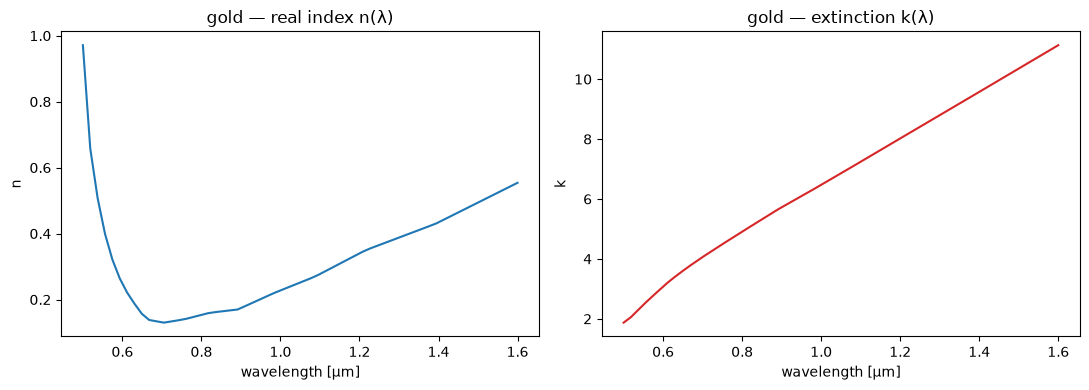

In [2]:
fig, (axn, axk) = plt.subplots(1, 2, figsize=(11, 4))
axn.plot(WL, n_rii, color="C0")
axn.set(xlabel="wavelength [µm]", ylabel="n", title="gold — real index n(λ)")
axk.plot(WL, k_rii, color="C3")
axk.set(xlabel="wavelength [µm]", ylabel="k", title="gold — extinction k(λ)")
fig.tight_layout()
plt.show()

## tidy3d — fit to a dispersive medium

`RiiMaterial.to_tidy3d_medium()` fits the tabulated `n, k` to a pole-residue
dispersive medium you drop straight into a `td.Simulation`. We evaluate the
fitted medium back over the band and overlay it on the input.

In [3]:
import tidy3d as td  # noqa: E402

medium = au.to_tidy3d_medium(wavelength_um=WL, max_num_poles=6)
nk_td = np.array([[float(x) for x in medium.nk_model(C / (w * 1e-6))] for w in WL])
print(f"tidy3d dispersive medium: max |Δn|={np.max(np.abs(nk_td[:, 0] - n_rii)):.3f}, "
      f"max |Δk|={np.max(np.abs(nk_td[:, 1] - k_rii)):.3f}")

22:35:55 PDT WARNING: Using canonical configuration directory at                
             '/home/mustafa/.config/tidy3d'. Found legacy directory at          
             '~/.tidy3d', which will be ignored. Remove it manually or run      
             'tidy3d config migrate --delete-legacy' to clean up.               

Output()

22:36:03 PDT WARNING: Unable to fit with weighted RMS error under               
             'tolerance_rms' of 1e-05                                           

tidy3d dispersive medium: max |Δn|=0.052, max |Δk|=0.106


## Lumerical — a sampled material

Lumerical takes the model as a **sampled material**: the `(frequency,
permittivity)` table itself. It stores the data verbatim, so it reproduces
the refractiveindex.info model almost exactly. (Needs a Lumerical
license; skipped gracefully without one.)

In [4]:
nk_lum = None
try:
    import lumapi

    f_hz = C / (WL * 1e-6)
    eps = (n_rii + 1j * k_rii) ** 2
    fdtd = lumapi.FDTD(hide=True)
    name = fdtd.addmaterial("Sampled 3D data")
    fdtd.setmaterial(name, "sampled data", np.column_stack([f_hz, eps]))
    nk_lum = np.array([complex(np.asarray(fdtd.getindex(name, float(fi))).ravel()[0]) for fi in f_hz])
    nk_lum = np.column_stack([nk_lum.real, np.abs(nk_lum.imag)])
    fdtd.close()
    print(f"lumerical sampled material: max |Δn|={np.max(np.abs(nk_lum[:, 0] - n_rii)):.4f}, "
          f"max |Δk|={np.max(np.abs(nk_lum[:, 1] - k_rii)):.4f}")
except Exception as e:  # noqa: BLE001 - license optional
    print(f"(Lumerical not available — skipping: {e})")

(Lumerical not available — skipping: 'appOpen error: \n Failed to start messaging, check licenses...Error: Could not connect to Ansys license server specified at 27025@ansys-rlm.ece.ubc.ca<br>Would you like to reconfigure your license settings?, Response: Yes\n')


## beamz — a single index (v1)

beamz v1 models each material as one constant `n + ik`, so a dispersive model
collapses to its value at your design wavelength. Fine for a narrow band;
just know it does not disperse.

In [5]:
DESIGN_WL = 1.55
nk_beamz = complex(au.nk_at(DESIGN_WL))
print(f"beamz constant @ {DESIGN_WL} µm: n + ik = {nk_beamz.real:.3f} + {nk_beamz.imag:.3f}i")

beamz constant @ 1.55 µm: n + ik = 0.524 + 10.742i


## The whole model, in every engine

The refractiveindex.info model (solid), the tidy3d fit (dots), the Lumerical
sampled material (dashes), and the beamz constant (flat). tidy3d and Lumerical
carry the full complex dispersion; beamz pins a single point.

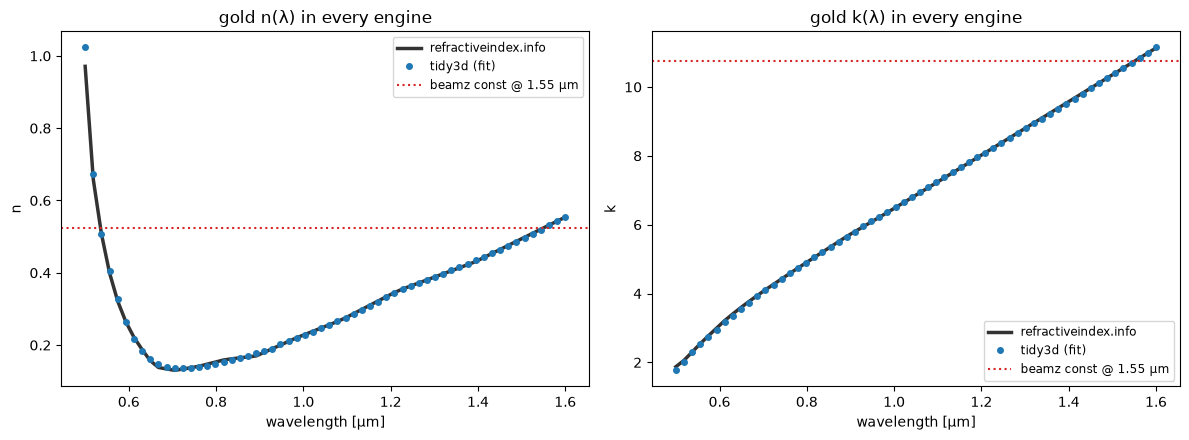

In [6]:
fig, (axn, axk) = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, comp, rii, lab in ((axn, 0, n_rii, "n"), (axk, 1, k_rii, "k")):
    ax.plot(WL, rii, "-", lw=2.5, color="0.2", label="refractiveindex.info")
    ax.plot(WL, nk_td[:, comp], "o", ms=4, color="C0", label="tidy3d (fit)")
    if nk_lum is not None:
        ax.plot(WL, nk_lum[:, comp], "--", lw=1.5, color="C1", label="Lumerical (sampled)")
    ax.axhline((nk_beamz.real, nk_beamz.imag)[comp], ls=":", color="C3",
               label=f"beamz const @ {DESIGN_WL} µm")
    ax.set(xlabel="wavelength [µm]", ylabel=lab, title=f"gold {lab}(λ) in every engine")
    ax.legend(fontsize="small")
fig.tight_layout()
plt.show()

## Using it in a simulation

`to_tidy3d_medium()` returns a real `td.Medium` you can assign to any
structure, and the Lumerical sampled material is a named material like any
other — so a device built with a refractiveindex.info model runs exactly like
one built with a vendor model:

```python
medium = load_rii_material("main", "Si", "Salzberg").to_tidy3d_medium()
structure = td.Structure(geometry=..., medium=medium)   # dispersive Si, from rii
```

## Doing this from the technology file

You rarely call these by hand. In the tech file, give a material an `rii:`
reference and (optionally) `source: rii`, and **every** engine builds its
material from that model automatically — tidy3d a dispersive medium, Lumerical
a sampled material, beamz a constant.

The shared `examples/tech.yaml` does this live: its **substrate** carries all
three sources and pins `source: rii`, so the buried oxide comes from the
Malitson (1965) Sellmeier page no matter which engine runs the job:

```yaml
materials:
  SiO2_rii:
    nk: 1.444                          # neutral constant fallback
    tidy3d: 1.444                      # eda source, tidy3d flavor
    lumerical: SiO2 (Glass) - Palik    # eda source, Lumerical flavor
    rii: {shelf: main, book: SiO2, page: Malitson}
    source: rii        # <- overrides the eda→rii→nk precedence on EVERY engine

substrate: {z_base: 0.0, z_span: -2, material: SiO2_rii}
```

`select_source` is the function every engine calls to make this choice — ask
it directly what each one would do:

In [7]:
from gds_fdtd.materials.select import select_source  # noqa: E402
from gds_fdtd.technology import Technology  # noqa: E402

tech = Technology.from_yaml(_find("examples/tech.yaml"))
d = tech.to_solver_dict()
substrate = d["substrate"][0]["material"]
superstrate = d["superstrate"][0]["material"]

print(f"{'material':12s}  {'tidy3d':10s}  {'lumerical':10s}  {'beamz':10s}")
for label, mat in [("substrate", substrate), ("superstrate", superstrate)]:
    picks = [select_source(mat, eng, name=label) for eng in ("tidy3d", "lumerical", "beamz")]
    print(f"{label:12s}  {picks[0]:10s}  {picks[1]:10s}  {picks[2]:10s}")

material      tidy3d      lumerical   beamz     
substrate     rii         rii         rii       
superstrate   eda         eda         nk        


The superstrate (no `source:` pin) shows the default precedence: engines with
a vendor database use it (`eda`), beamz falls through to `nk`. The pinned
substrate answers `rii` everywhere. On tidy3d that buys real dispersion —
the medium built from the tech file is a Sellmeier fit, not a constant:

In [8]:
import os  # noqa: E402

os.environ["GDS_FDTD_RII_DB"] = str(RII_DB)  # engines that build the substrate need the DB

sio2 = tech.substrate.material.rii.load()  # the named material, resolved onto the layer
medium = sio2.to_tidy3d_medium(wavelength_um=np.linspace(1.5, 1.6, 11))
wl = np.array([1.50, 1.55, 1.60])
n_fit = np.sqrt(medium.eps_model(td.C_0 / wl)).real
for w, n_r in zip(wl, n_fit, strict=True):
    print(f"λ={w:.2f} µm   rii n={sio2.n_at(w):.6f}   tidy3d medium n={n_r:.6f}")

Output()

λ=1.50 µm   rii n=1.444618   tidy3d medium n=1.444639
λ=1.55 µm   rii n=1.444024   tidy3d medium n=1.444010
λ=1.60 µm   rii n=1.443419   tidy3d medium n=1.443440


The selection rule (per material, per engine) is **eda → rii → nk**, with
`source:` as an explicit override and a clear error if nothing applies — see
`docs/technology.rst` → *Material sources*.

## Recap

A refractiveindex.info page is a portable, engine-independent source of truth:
its full `n(λ) + i·k(λ)` flows into tidy3d (a dispersion fit) and Lumerical (a
sampled material) intact, and into beamz as a single-wavelength constant. Pin
it with `source: rii` — as the shipped tech file does for its substrate — and
every engine models that material from the same measured page.